In [8]:
import numpy as np
from scipy import interpolate as interp
import matplotlib.pyplot as plt
import matplotlib as mpl
import math

import torch
from torch import nn
import fitstream as fts

mpl.rcParams['figure.dpi'] = 140

# General functions

In [25]:
def random_func(m: int, sigma: float=1., lower=-3, upper=3, rng: np.random.Generator = None):
    if rng is None:
        rng = np.random.default_rng(42)
    
    ts = np.linspace(lower, upper, m)
    ys = rng.normal(0.0, sigma, size=m)
    return interp.CubicSpline(ts, ys, bc_type="natural", extrapolate=True)

In [28]:
def func_gallery(random_func_fn, rng, ms=[3, 5, 10, 20]):
    n_cols = int(math.ceil(math.sqrt(len(ms))))
    n_rows = int(math.ceil(len(ms) / n_cols))

    fig, axs = plt.subplots(n_rows, n_cols, figsize=(4 * n_cols, 3 * n_rows), layout='constrained')
    xs = np.linspace(-4, 4, 1000)

    for m, ax in zip(ms, axs.ravel()):
        func = random_func_fn(m)
        ax.plot(xs, func(xs))
        ax.set_title(f'$f_{{{m}}}(x)$')

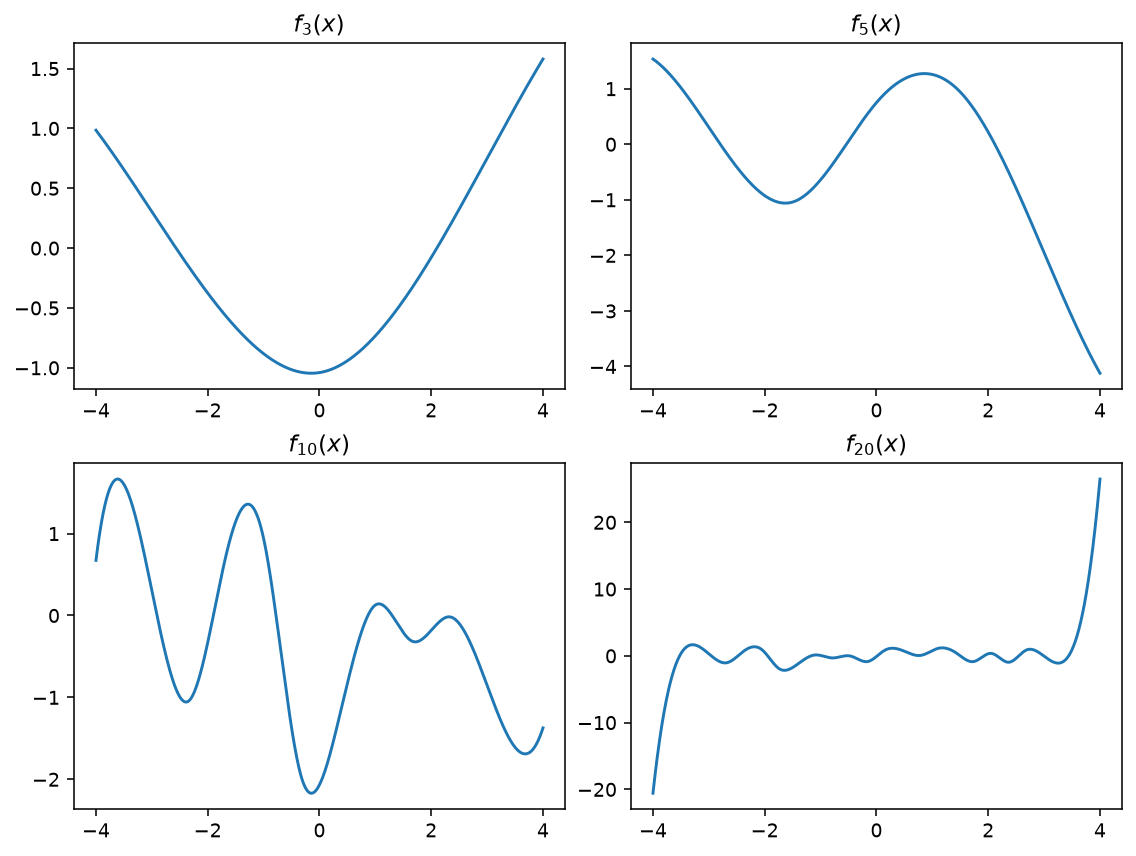

In [29]:
func_gallery(random_func, np.random.default_rng(42))